# **`Inatel - C24 (Inteligência Artificial) - 2026/1`**

# <font color='green'>**Atividade 08: RNN**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte o material disponibilizado pelo Prof. Felipe Figueiredo para revisar os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**A ATIVIDADE DEVERÁ SER REALIZADA COM O [MONITOR](mailto:matheus.botelho@ges.inatel.br) EM UM DOS SEGUINTES HORÁRIOS:**</font>

| Monitor                       | Dia           | Hora                               | Local           |
|-------------------------------|---------------|------------------------------------|---------------- |
| Matheus Botelho Sampaio Netto | Terça-feira   | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Quinta-feira  | <font color='orange'>17:30</font>  | 1.4 (prédio VI) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>10:00</font> | Teams (ao vivo) |
| Matheus Botelho Sampaio Netto | Sábado        | <font color='#2D9CDB'>13:30</font> | Teams (ao vivo) |

- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação.</font>
  - Exemplo: `!pip install nome_da_biblioteca`
- <font color='red'>**Renomeie os termos `LL` para `sua_turma_de_laboratorio` e `MMMM` para `seu_numero_de_matricula` no nome do arquivo.**</font>
  - Exemplo: `C24_2026_1_L1_Atividade_08_1234.ipynb`)
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

# <font color='green'><u><b>Preparação</b></u></font>

In [2]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
import os

from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

# <font color='green'><u><b>Parte 1 - Conjunto de Dados</b></u></font>

Não altere o conteúdo da célula a seguir!

In [4]:
zip_path = tf.keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    cache_dir=os.getcwd(),
    extract=True
)

csv_path = os.path.join(os.path.splitext(zip_path)[0], 'jena_climate_2009_2016.csv')

target_col = "T (degC)"

temperature = pd.read_csv(csv_path)[target_col].values.reshape(-1, 1)

temperature

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


array([[-8.02],
       [-8.41],
       [-8.51],
       ...,
       [-3.16],
       [-4.23],
       [-4.82]])

### <font color='#2D9CDB'>Q1) O dataset [Jena Climate](https://www.kaggle.com/datasets/mnassrib/jena-climate) é amplamente utilizado no estudo de redes neurais recorrentes (RNNs), LSTMs e previsão de séries temporais. Pesquise brevemente sobre o dataset e descreva, em um único parágrafo, o domínio de aplicação da base de dados, o objetivo para o qual ela foi criada, o período de coleta dos dados, os tipos de variáveis meteorológicas registradas e por que esse conjunto de dados é adequado para problemas de previsão temporal utilizando redes neurais recorrentes.</font>

O Jena Climate Dataset reúne medições meteorológicas feitas em Jena, Alemanha, entre 2009 e 2016, com registros a cada 10 minutos de variáveis como temperatura, pressão, umidade, ponto de orvalho, velocidade e direção do vento, densidade do ar e vapor de água. Criado para estudos de previsão e análise climática, seu domínio de aplicação é a modelagem de séries temporais, especialmente com redes neurais recorrentes (RNNs) e LSTMs. A alta resolução temporal e a diversidade de variáveis tornam o conjunto ideal para capturar padrões complexos e dependências de longo prazo, o que o torna amplamente utilizado em pesquisas de previsão meteorológica e aprendizado profundo.

### <font color='#2D9CDB'>Q2) Utilizando a variável <code>temperature</code>, plote a série temporal completa de temperaturas registradas no dataset. Em seguida, informe a quantidade total de amostras, a temperatura mínima, a temperatura máxima, a temperatura média e o desvio padrão da série. Com base no gráfico obtido, descreva brevemente os padrões observados, comentando sobre possíveis tendências, sazonalidades e variações ao longo do tempo.</font>

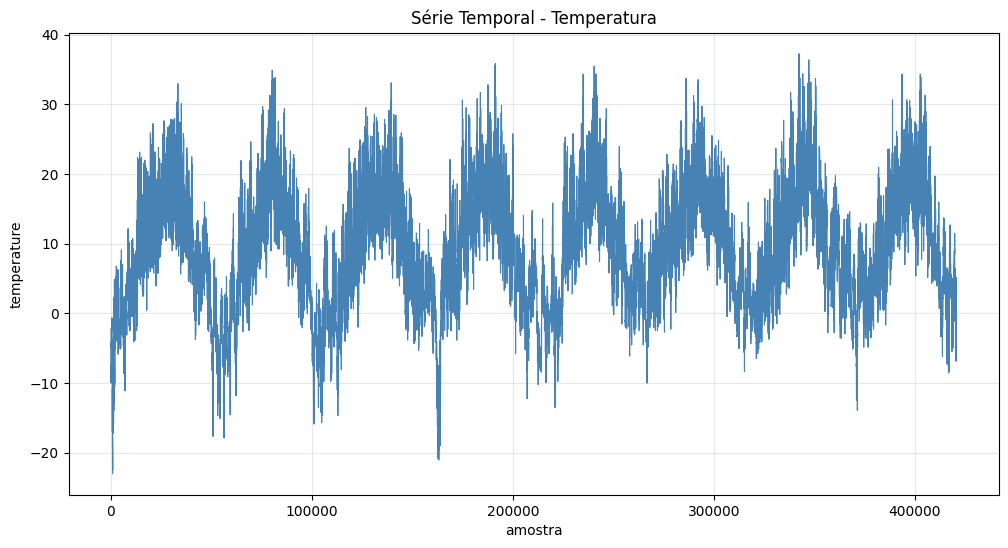

Quantidade de amostras: 420551
Temperatura mínima: -23.01
Temperatura máxima: 37.28
Temperatura média: 9.450147354304233
Desvio padrão: 8.423355195701777


In [5]:
plt.figure(figsize=(12,6))
plt.plot(temperature, color='steelblue', linewidth=0.8)
plt.title("Série Temporal - Temperatura")
plt.xlabel("amostra")
plt.ylabel("temperature")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Quantidade de amostras: {len(temperature)}")
print(f"Temperatura mínima: {np.min(temperature)}")
print(f"Temperatura máxima: {np.max(temperature)}")
print(f"Temperatura média: {np.mean(temperature)}")
print(f"Desvio padrão: {np.std(temperature)}")

O gráfico da série temporal de temperature mostra padrões bem definidos: há uma sazonalidade anual, com picos de calor nos meses de verão e quedas acentuadas no inverno, repetindo-se de forma cíclica ao longo dos anos. Observa-se também uma variação de curto prazo que refletem mudanças diárias e semanais nas condições climáticas. A tendência geral da série é estável, sem indícios de aquecimento ou resfriamento progressivo no período analisado, mas com amplitudes significativas. Esses ciclos e flutuações tornam os dados ideais para estudos de previsão temporal, já que combinam padrões de longo prazo (sazonalidade) com variações de alta frequência.

### <font color='#2D9CDB'>Q3) Divida a série temporal em três subconjuntos: treinamento (60%), validação (20%) e teste (20%), preservando a ordem temporal das amostras. Informe a quantidade de amostras em cada subconjunto e explique por que, em problemas de previsão temporal, não é adequado embaralhar os dados antes da divisão.</font>

In [6]:
# Divisão treino / teste e validaçao (60% / 40%)
split = int(len(temperature) * 0.6)
temp_treino, temp_teste_val = temperature[:split], temperature[split:]

split = int(len(temp_teste_val) * 0.5)
temp_teste, temp_val = temp_teste_val[:split], temp_teste_val[split:]

print(f"   treino: {len(temp_treino)} amostras")
print(f"   teste:  {len(temp_teste)} amostras")
print(f"   validação:  {len(temp_val)} amostras")

   treino: 252330 amostras
   teste:  84110 amostras
   validação:  84111 amostras


 Porque a ordem cronológica carrega a informação essencial que o modelo precisa aprender. A série temporal é composta por dependências entre valores passados e futuros; se você embaralha, perde essa sequência e mistura pontos de diferentes períodos, quebrando padrões de tendência e sazonalidade. Isso faria com que o modelo treinasse em dados fora de contexto e testasse em situações irreais, já que na prática sempre usamos o passado para prever o futuro.

### <font color='#2D9CDB'>Q4) Normalize os conjuntos de treinamento, validação e teste utilizando a técnica Min-Max Scaling, de forma que os valores fiquem no intervalo [0, 1]. Apresente os valores mínimo e máximo do conjunto de treinamento antes e depois da normalização e explique brevemente por que a normalização é importante para o treinamento de redes neurais.</font>

In [7]:
print(f"Temperatura mínima do conjunto de treino: {np.min(temp_treino)}")
print(f"Temperatura máxima do conjunto de treino: {np.max(temp_treino)}")

scaler = MinMaxScaler(feature_range=(0, 1))
temp_treino_scaled = scaler.fit_transform(temp_treino.reshape(-1, 1))
temp_teste_scaled = scaler.transform(temp_teste.reshape(-1, 1))
temp_val_scaled = scaler.transform(temp_val.reshape(-1, 1))

print(f"Temperatura mínima do conjunto de treino normalizado: {np.min(temp_treino_scaled)}")
print(f"Temperatura máxima do conjunto de treino normalizado: {np.max(temp_treino_scaled)}")

Temperatura mínima do conjunto de treino: -23.01
Temperatura máxima do conjunto de treino: 35.86
Temperatura mínima do conjunto de treino normalizado: 0.0
Temperatura máxima do conjunto de treino normalizado: 1.0


A normalização é importante no treinamento de redes neurais porque garante que todas as variáveis de entrada estejam na mesma escala, evitando que atributos com valores muito grandes dominem o aprendizado.

# <font color='green'><u><b>Parte 2 - Preparação das Séries Temporais</b></u></font>

### <font color='#2D9CDB'>Q5) Para treinar uma LSTM, é necessário organizar a série temporal em sequências de entrada e saídas desejadas. Implemente uma função chamada <code>create_sequences()</code> que utilize uma janela temporal de 30 amostras, de forma que cada entrada seja composta pelas 30 temperaturas anteriores e a saída corresponda à temperatura seguinte. Gere os conjuntos de treinamento, validação e teste e informe as dimensões de <code>X_train</code> e <code>y_train</code>. Explique brevemente o significado de cada dimensão.</font>

In [8]:
def create_sequences(dataset, window_size):
    X, y = [], []
    for i in range(len(dataset) - window_size):
        X.append(dataset[i:i+window_size])
        y.append(dataset[i+window_size])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(temp_treino_scaled, 30)
X_test, y_test = create_sequences(temp_teste_scaled, 30)
X_val, y_val = create_sequences(temp_val_scaled, 30)

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

X_train: (252300, 30, 1)
y_train: (252300, 1)


As dimensões de X_train e y_train refletem como os dados foram organizados para alimentar a LSTM. No caso de X_train: (252300, 30, 1), o primeiro número indica a quantidade total de amostras de treino (252.300 janelas criadas), o segundo corresponde ao tamanho da janela temporal (30 passos anteriores usados como entrada) e o último representa o número de variáveis por passo (apenas uma, a temperatura). Já em y_train: (252300, 1), o primeiro número mostra que há uma saída para cada janela de entrada, e o segundo indica que cada saída é composta por um único valor, a temperatura imediatamente seguinte à sequência. Em resumo, cada exemplo de treino é formado por 30 valores consecutivos de temperatura como entrada e um valor de temperatura como alvo de previsão.

### <font color='#2D9CDB'>Q6) Exiba graficamente a primeira sequência presente em <code>X_train</code> e destaque o valor correspondente em <code>y_train</code>. Explique como essa sequência será utilizada pela LSTM para realizar a previsão da próxima temperatura.</font>

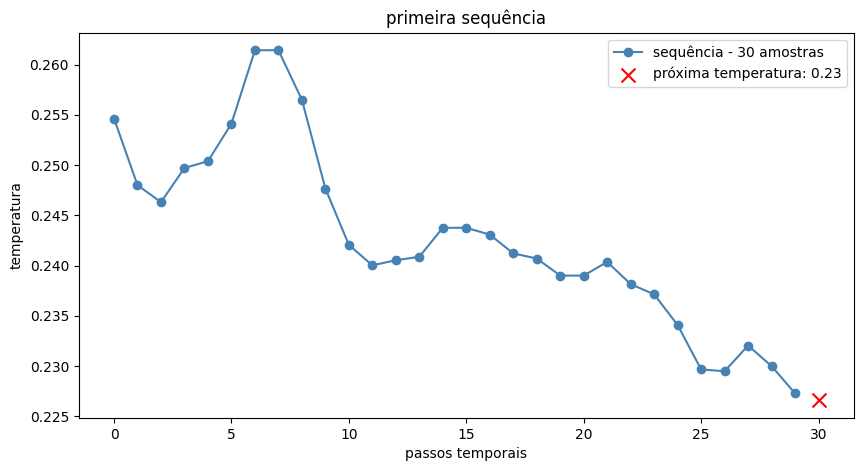

In [9]:
plt.figure(figsize=(10,5))
plt.plot(range(len(X_train[0])), X_train[0], marker='o', color='steelblue', label="sequência - 30 amostras")
plt.scatter(len(X_train[0]), y_train[0], color='red', marker='x', s=100, label=f"próxima temperatura: {y_train[0][0]:.2f}")
plt.title("primeira sequência")
plt.xlabel("passos temporais")
plt.ylabel("temperatura")
plt.legend()
plt.show()


A primeira sequência de X_train contém os 30 valores anteriores de temperatura e o ponto em y_train é a temperatura seguinte. A LSTM usa essa janela como contexto: ela lê os 30 valores em ordem, guarda padrões de subida ou descida na memória interna e, com base nisso, aprende a prever o próximo valor. Em outras palavras, a sequência azul é a entrada e o ponto vermelho é o alvo que a rede deve acertar.

# <font color='green'><u><b>Parte 3 - Construindo a Primeira LSTM</b></u></font>

### <font color='#2D9CDB'>Q7) Construa uma rede neural recorrente composta por uma camada LSTM com uma unidade de memória e uma camada de saída totalmente conectada com um neurônio. Utilize a função de perda MSE (<code>mean_squared_error</code>) e o otimizador Adam. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo.</font>

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense


modelo = Sequential([
    # shape = (timesteps, features) = (30, 1)
    Input(shape=(30, 1)),

    # Camada LSTM com 1 unidade
    LSTM(1),

    # Camada de saída: 1 neurônio → prevê o próximo valor
    Dense(1)
])

modelo.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (56.00 B)

 Trainable params: 14 (56.00 B)

 Non-trainable params: 0 (0.00 B)

O número total de parâmetros treináveis do modelo é 14.

### <font color='#2D9CDB'>Q8) Treine o modelo por 10 épocas utilizando os conjuntos de treinamento e validação. Em seguida, plote as curvas de perda de treinamento e validação ao longo das épocas. Com base nos gráficos obtidos, descreva brevemente o comportamento do treinamento e indique se há evidências de sobreajuste (overfitting) ou problemas de generalização.</font>

Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 0.0059 - val_loss: 1.3117e-04
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 7.7865e-05 - val_loss: 5.1307e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 4.3030e-05 - val_loss: 3.4352e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 3.1400e-05 - val_loss: 2.7465e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 2.5565e-05 - val_loss: 2.3929e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 2.2052e-05 - val_loss: 2.1722e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.9724e-05 - val_loss: 2.0110e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.8099e-05 - val_loss: 1.8859e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.6936e-05 - val_loss: 1.7890e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.6101e-05 - val_loss: 1.7158e-05


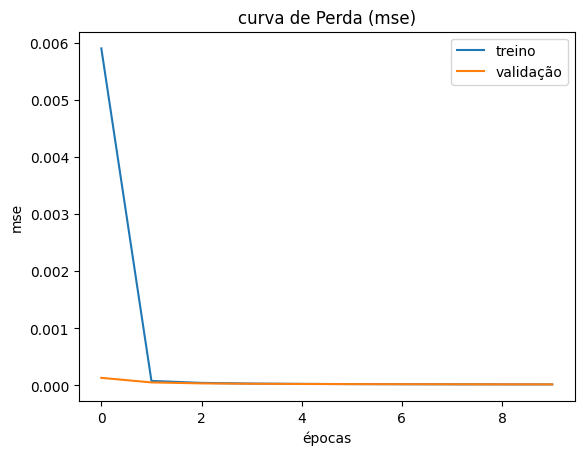

In [11]:
history = modelo.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

plt.plot(history.history['loss'], label='treino')
plt.plot(history.history['val_loss'], label='validação')
plt.title('curva de Perda (mse)')
plt.xlabel('épocas')
plt.ylabel('mse')
plt.legend()

As curvas de perda mostram que tanto o erro de treinamento quanto o de validação caem rapidamente nas primeiras épocas e depois se estabilizam em valores baixos. Isso indica que o modelo conseguiu aprender o padrão da série temporal de forma consistente. Como as duas curvas permanecem próximas e não há aumento significativo da perda de validação em relação à de treino, não há evidências de sobreajuste (overfitting) ou problemas de generalização nesse caso. O comportamento sugere que o modelo está conseguindo generalizar bem para os dados de validação.

### <font color='#2D9CDB'>Q9) Avalie o modelo utilizando o conjunto de teste e reporte o valor do erro quadrático médio (MSE). Em seguida, explique brevemente o que essa métrica representa no contexto do problema de previsão de temperatura.</font>

In [12]:
mse1 = modelo.evaluate(X_test, y_test)
print(mse1)

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 1.5841e-05
1.584094025020022e-05


 Essa métrica indica o quanto, em média, as previsões da rede se afastam dos valores reais, quanto menor, mais confiável é o modelo para antecipar a próxima temperatura.

### <font color='#2D9CDB'>Q10) Utilize o modelo treinado para gerar previsões no conjunto de teste. Plote em um mesmo gráfico os valores reais e previstos para as 100 primeiras amostras do conjunto de teste e descreva brevemente a qualidade das previsões obtidas.</font>

2628/2628 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step


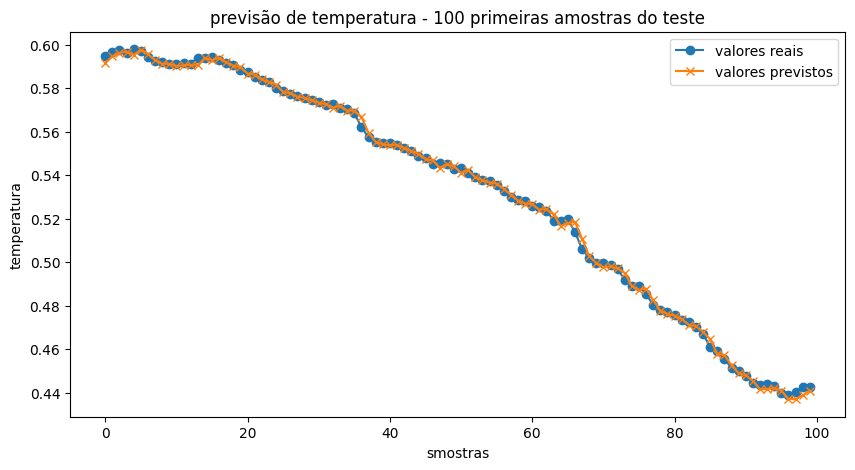

In [13]:
y_pred = modelo.predict(X_test)

plt.figure(figsize=(10,5))
plt.plot(y_test[:100], label='valores reais', marker='o')
plt.plot(y_pred[:100], label='valores previstos', marker='x')
plt.title('previsão de temperatura - 100 primeiras amostras do teste')
plt.xlabel('smostras')
plt.ylabel('temperatura')
plt.legend()
plt.show()

As previsões obtidas apresentam alta qualidade: os valores previstos acompanham de perto os valores reais, com pontos praticamente sobrepostos nas primeiras 100 amostras do conjunto de teste. Isso mostra que o modelo conseguiu capturar bem os padrões da série temporal de temperatura, mantendo erros muito baixos.

# <font color='green'><u><b>Parte 4 - Comparação de Arquiteturas</b></u></font>

### <font color='#2D9CDB'>Q11) Modifique a arquitetura da rede para utilizar 10 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 1.0692e-04 - val_loss: 2.3901e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.8934e-05 - val_loss: 1.5166e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3991e-05 - val_loss: 1.3784e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3736e-05 - val_loss: 1.2704e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - loss: 1.3595e-05 - val_loss: 1.2301e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3499e-05 - val_loss: 1.2255e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3423e-05 - val_loss: 1.2403e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3359e-05 - val_loss: 1.2611e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.3303e-05 - val_loss: 1.2741e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3246e-05 - val_loss: 1.2724e-05
2628/2628 ━━━━━━━━━━━━━━

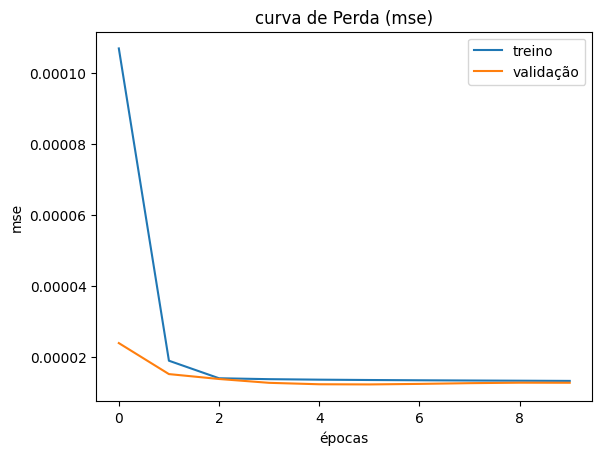

In [14]:
modelo = Sequential([
    # shape = (timesteps, features) = (30, 1)
    Input(shape=(30, 1)),

    # Camada LSTM com 10 unidades
    LSTM(10),

    # Camada de saída: 1 neurônio → prevê o próximo valor
    Dense(1)
])

modelo.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

print(modelo.summary())

history = modelo.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

plt.plot(history.history['loss'], label='treino')
plt.plot(history.history['val_loss'], label='validação')
plt.title('curva de Perda (mse)')
plt.xlabel('épocas')
plt.ylabel('mse')
plt.legend()

mse10 = modelo.evaluate(X_test, y_test)
print(mse10)

### <font color='#2D9CDB'>Q12) Repita o experimento utilizando 20 unidades na camada LSTM. Apresente o resumo da arquitetura gerado pelo método <code>summary()</code> e informe o número total de parâmetros treináveis do modelo. Em seguida, treine a rede por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,781 (6.96 KB)

 Trainable params: 1,781 (6.96 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 0.0011 - val_loss: 4.0190e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 2.9492e-05 - val_loss: 1.5859e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.5456e-05 - val_loss: 1.3032e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.4198e-05 - val_loss: 1.5277e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.3860e-05 - val_loss: 1.3226e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 49s 6ms/step - loss: 1.3664e-05 - val_loss: 1.2281e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.3489e-05 - val_loss: 1.2431e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 50s 6ms/step - loss: 1.3372e-05 - val_loss: 1.2509e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.3272e-05 - val_loss: 1.2443e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 48s 6ms/step - loss: 1.3184e-05 - val_loss: 1.2375e-05
2628/2628 ━━━━━━━━━━━━━━━━━━

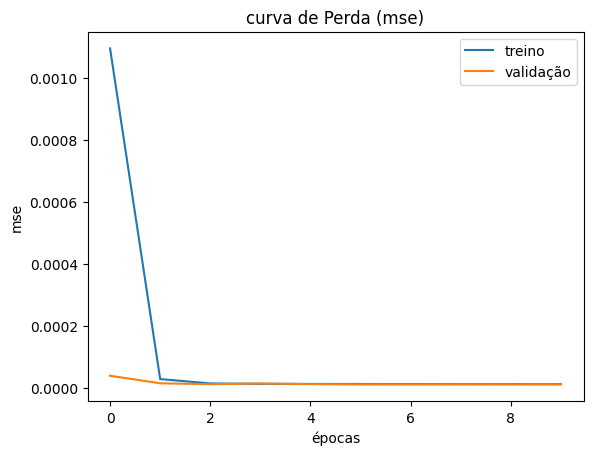

In [15]:
modelo = Sequential([
    # shape = (timesteps, features) = (30, 1)
    Input(shape=(30, 1)),

    # Camada LSTM com 10 unidades
    LSTM(20),

    # Camada de saída: 1 neurônio → prevê o próximo valor
    Dense(1)
])

modelo.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

print(modelo.summary())

history = modelo.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

plt.plot(history.history['loss'], label='treino')
plt.plot(history.history['val_loss'], label='validação')
plt.title('curva de Perda (mse)')
plt.xlabel('épocas')
plt.ylabel('mse')
plt.legend()

mse20 = modelo.evaluate(X_test, y_test)
print(mse20)

### <font color='#2D9CDB'>Q13) Compare os modelos com 1, 10 e 20 unidades na camada LSTM em termos de número de parâmetros treináveis e desempenho no conjunto de teste. Organize os resultados em uma tabela contendo a quantidade de unidades LSTM, o número de parâmetros treináveis e o valor de MSE. Com base nos resultados obtidos, discuta brevemente a relação entre a complexidade do modelo e sua capacidade preditiva.</font>

In [16]:
dados = {
    "Unidades LSTM": [1, 10, 20],
    "Parâmetros treináveis": [14, 491, 1541],
    "MSE (teste)": [mse1, mse10, mse20]
}

df = pd.DataFrame(dados)
print(df)


   Unidades LSTM  Parâmetros treináveis  MSE (teste)
0              1                     14     0.000016
1             10                    491     0.000012
2             20                   1541     0.000012


O aumento das unidades LSTM faz o número de parâmetros crescer rapidamente. O MSE melhora levemente, mas os ganhos são marginais após 10 unidades. Mais complexidade aumenta a capacidade de aprendizado, mas também o custo computacional e o risco de sobreajuste.

# <font color='green'><u><b>Parte 5 - Influência da Janela Temporal</b></u></font>

### <font color='#2D9CDB'>Q14) Repita o experimento utilizando uma janela temporal de 15 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 46s 6ms/step - loss: 3.3470e-04 - val_loss: 3.9216e-05
Epoch 2/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - loss: 2.7673e-05 - val_loss: 1.8570e-05
Epoch 3/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - loss: 1.6924e-05 - val_loss: 1.2867e-05
Epoch 4/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 43s 5ms/step - loss: 1.4104e-05 - val_loss: 1.7150e-05
Epoch 5/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - loss: 1.3699e-05 - val_loss: 1.9727e-05
Epoch 6/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 44s 6ms/step - loss: 1.3531e-05 - val_loss: 1.6298e-05
Epoch 7/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 52s 7ms/step - loss: 1.3416e-05 - val_loss: 1.3019e-05
Epoch 8/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 81s 6ms/step - loss: 1.3311e-05 - val_loss: 1.2273e-05
Epoch 9/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 52s 7ms/step - loss: 1.3206e-05 - val_loss: 1.2447e-05
Epoch 10/10
7885/7885 ━━━━━━━━━━━━━━━━━━━━ 76s 6ms/step - loss: 1.3116e-05 - val_loss: 1.2424e-05
2628/2628 ━━━━━━━━━━━━━━

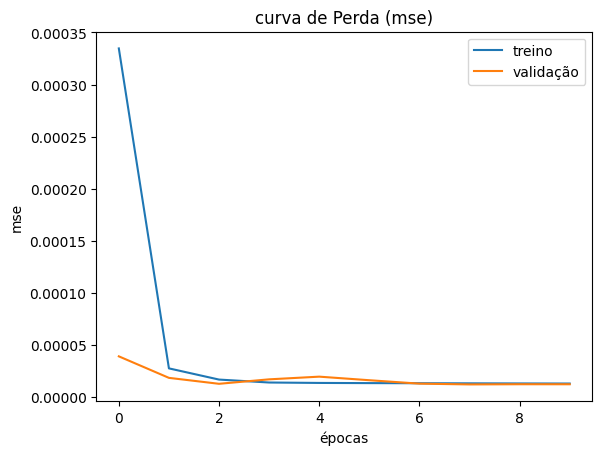

In [17]:
X_train, y_train = create_sequences(temp_treino_scaled, 15)
X_test, y_test = create_sequences(temp_teste_scaled, 15)
X_val, y_val = create_sequences(temp_val_scaled, 15)

modelo = Sequential([
    # shape = (timesteps, features)
    Input(shape=(15, 1)),

    # Camada LSTM com 10 unidades
    LSTM(10),

    # Camada de saída: 1 neurônio → prevê o próximo valor
    Dense(1)
])

modelo.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

print(modelo.summary())

history = modelo.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

plt.plot(history.history['loss'], label='treino')
plt.plot(history.history['val_loss'], label='validação')
plt.title('curva de Perda (mse)')
plt.xlabel('épocas')
plt.ylabel('mse')
plt.legend()

mse15 = modelo.evaluate(X_test, y_test)
print(mse15)

### <font color='#2D9CDB'>Q15) Repita o experimento utilizando uma janela temporal de 60 amostras e uma camada LSTM com 10 unidades. Treine o modelo por 10 épocas, avalie o modelo no conjunto de teste e reporte o valor de MSE obtido.</font>

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 10)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 491 (1.92 KB)

 Trainable params: 491 (1.92 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 58s 7ms/step - loss: 0.0013 - val_loss: 4.0733e-05
Epoch 2/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 2.7143e-05 - val_loss: 1.6932e-05
Epoch 3/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 92s 8ms/step - loss: 1.5822e-05 - val_loss: 1.3040e-05
Epoch 4/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 55s 7ms/step - loss: 1.3849e-05 - val_loss: 1.2686e-05
Epoch 5/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 58s 7ms/step - loss: 1.3581e-05 - val_loss: 1.3206e-05
Epoch 6/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 1.3380e-05 - val_loss: 1.2584e-05
Epoch 7/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 83s 7ms/step - loss: 1.3257e-05 - val_loss: 1.2334e-05
Epoch 8/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 1.3163e-05 - val_loss: 1.2257e-05
Epoch 9/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 63s 8ms/step - loss: 1.3090e-05 - val_loss: 1.2238e-05
Epoch 10/10
7884/7884 ━━━━━━━━━━━━━━━━━━━━ 56s 7ms/step - loss: 1.3031e-05 - val_loss: 1.2182e-05
2627/2627 ━━━━━━━━━━━━━━━━━━

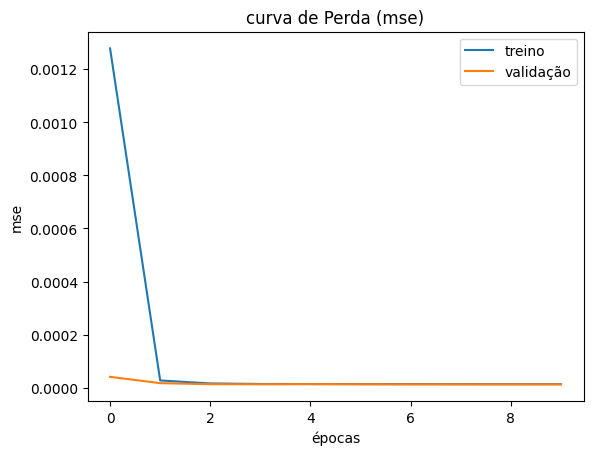

In [18]:
X_train, y_train = create_sequences(temp_treino_scaled, 60)
X_test, y_test = create_sequences(temp_teste_scaled, 60)
X_val, y_val = create_sequences(temp_val_scaled, 60)

modelo = Sequential([
    # shape = (timesteps, features)
    Input(shape=(60, 1)),

    # Camada LSTM com 10 unidades
    LSTM(10),

    # Camada de saída: 1 neurônio → prevê o próximo valor
    Dense(1)
])

modelo.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

print(modelo.summary())

history = modelo.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

plt.plot(history.history['loss'], label='treino')
plt.plot(history.history['val_loss'], label='validação')
plt.title('curva de Perda (mse)')
plt.xlabel('épocas')
plt.ylabel('mse')
plt.legend()

mse60 = modelo.evaluate(X_test, y_test)
print(mse60)

### <font color='#2D9CDB'>Q16) Compare os resultados obtidos para janelas temporais de 15, 30 e 60 amostras utilizando uma camada LSTM com 10 unidades. Organize os resultados em uma tabela contendo o tamanho da janela temporal, o valor de MSE e uma estimativa do tempo médio de treinamento por época (dica: utilize os valores exibidos nos logs de treinamento). Com base nos resultados, discuta brevemente o impacto do tamanho da janela temporal no desempenho e no custo computacional do modelo.</font>

In [19]:
dados = {
    "Tamanho da janela temporal": [15, 30, 60],
    "MSE (teste)": [mse15, mse10, mse60],
    "Tempo médio de treinamento por época": ['44s', '49s', '60s'],
}

df = pd.DataFrame(dados)
print(df)

   Tamanho da janela temporal  MSE (teste)  \
0                          15     0.000012   
1                          30     0.000012   
2                          60     0.000011   

  Tempo médio de treinamento por época  
0                                  44s  
1                                  49s  
2                                  60s  


O tamanho da janela temporal influencia diretamente tanto o desempenho quanto o custo computacional do modelo: janelas menores, como 15 amostras, já fornecem contexto suficiente para que a LSTM capture padrões relevantes, resultando em MSE muito baixo com tempo de treino reduzido; ao aumentar para 30 ou 60 amostras, o erro quadrático médio melhora apenas de forma marginal, enquanto o tempo por época cresce significativamente, já que o modelo precisa processar sequências mais longas. Assim, janelas maiores oferecem mais histórico, mas não trazem ganhos proporcionais em precisão, tornando janelas curtas ou médias mais eficientes em termos de equilíbrio entre qualidade da previsão e custo computacional.

# <font color='green'><u><b>Parte 6 - Análise Final</b></u></font>

### <font color='#2D9CDB'>Q17) Com base em todos os experimentos realizados nesta atividade, discuta os fatores que mais influenciaram o desempenho do modelo. Considere o impacto da quantidade de unidades LSTM, do tamanho da janela temporal e do custo computacional. Em sua opinião, qual configuração apresentou o melhor equilíbrio entre precisão e eficiência? Justifique sua resposta.</font>

Com base nos experimentos realizados, os fatores que mais influenciaram o desempenho do modelo foram a quantidade de unidades LSTM, o tamanho da janela temporal e o custo computacional. O aumento das unidades LSTM elevou significativamente o número de parâmetros treináveis, mas trouxe apenas ganhos marginais de precisão, enquanto janelas maiores forneceram mais contexto histórico, porém com impacto limitado no MSE e aumento expressivo no tempo de treinamento. Assim, a configuração com 10 unidades LSTM e janela temporal de 15 ou 30 amostras apresentou o melhor equilíbrio entre precisão e eficiência, pois manteve o erro quadrático médio em valores muito baixos e reduziu o custo computacional, mostrando-se suficiente para capturar os padrões da série temporal sem sobrecarregar o treinamento.